## 📚 0단계: 라이브러리 및 설정

In [6]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import glob
from collections import Counter
import time

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR

# 전처리 & 증강
from torchvision import models, transforms

# 평가
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 재현성
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
🎮 GPU: NVIDIA GeForce RTX 4060 Ti


## 📊 1단계: 데이터 로드

In [7]:
# 데이터 경로
FRAME_SAVE_ROOT = r"c:\Users\THKIM\Desktop\3-2 프로젝트\인공지능 프로젝트\data\Deep_Fake_datasets"

# 모든 얼굴 이미지 수집
face_img_paths = glob.glob(os.path.join(FRAME_SAVE_ROOT, "faces", "*", "*", "*", "*.jpg"))
print(f"✅ 총 얼굴 이미지: {len(face_img_paths):,}개")

# 메타데이터 생성
meta = []
for path in face_img_paths:
    norm_path = os.path.normpath(path)
    parts = norm_path.split(os.sep)
    
    if len(parts) < 6:
        continue
    
    dataset = parts[-4]
    split = parts[-3]
    label = parts[-2]
    fname = parts[-1]
    
    if label not in ["real", "fake"]:
        continue
    
    if dataset == "KoDF":
        split = "kodf"
    
    # Video ID 추출
    name_no_ext = os.path.splitext(fname)[0]
    
    if dataset == "KoDF":
        tokens = name_no_ext.split('_')
        video_id = tokens[0] if len(tokens) >= 2 else name_no_ext
    elif dataset == "FFPP":
        parts_name = name_no_ext.split('_')
        if len(parts_name) >= 4:
            video_part = '_'.join([p for p in parts_name[3:] if not p.startswith('f')])
            video_id = video_part if video_part else name_no_ext
        else:
            video_id = name_no_ext
    elif dataset == "CelebDF":
        parts_name = name_no_ext.split('_')
        video_id = parts_name[3] if len(parts_name) >= 4 else name_no_ext
    else:
        tokens = name_no_ext.split('_')
        video_id = tokens[0] if len(tokens) >= 2 else name_no_ext
    
    meta.append({
        "path": norm_path,
        "split": split,
        "label": label,
        "identity_id": dataset,
        "video_id": video_id,
        "original_video_id": video_id
    })

meta_df = pd.DataFrame(meta)
print(f"\n📋 메타데이터: {meta_df.shape}")
print(f"\n🏷️ Label 분포:\n{meta_df['label'].value_counts()}")
print(f"\n📁 Dataset 분포:\n{meta_df['identity_id'].value_counts()}")

✅ 총 얼굴 이미지: 75,643개

📋 메타데이터: (75643, 6)

🏷️ Label 분포:
label
fake    39383
real    36260
Name: count, dtype: int64

📁 Dataset 분포:
identity_id
KoDF       51166
FFPP       19329
CelebDF     5148
Name: count, dtype: int64


## 🔀 2단계: 누수 없는 Video-Level Split

In [8]:
# Stratified Group Split (70/20/10 video-level)
meta_df['strat_key'] = meta_df['identity_id'] + '_' + meta_df['label']

# Video 레벨로 변환
video_level_df = meta_df.groupby('video_id').first().reset_index()
print(f"📹 총 비디오 수: {len(video_level_df):,}개")

# 1) Test 10% (stratified by strat_key)
train_val_df, test_df_v = train_test_split(
    video_level_df,
    test_size=0.10,
    stratify=video_level_df['strat_key'],
    random_state=42,
)

# 2) Valid 20% of total -> 0.2/0.9 ≈ 0.2222 of remaining
valid_ratio = 0.2 / 0.9
train_df_v, valid_df_v = train_test_split(
    train_val_df,
    test_size=valid_ratio,
    stratify=train_val_df['strat_key'],
    random_state=42,
)

train_orig_vids = set(train_df_v['video_id'].values)
valid_orig_vids = set(valid_df_v['video_id'].values)
test_orig_vids = set(test_df_v['video_id'].values)

print("\n✅ Video Split (70/20/10):")
print(f"   Train: {len(train_orig_vids)} videos")
print(f"   Valid: {len(valid_orig_vids)} videos")
print(f"   Test:  {len(test_orig_vids)} videos")

# 누수 검증
leak_tv = len(train_orig_vids & valid_orig_vids)
leak_tt = len(train_orig_vids & test_orig_vids)
leak_vt = len(valid_orig_vids & test_orig_vids)

print("\n🔒 누수 검증:")
print(f"   Train ∩ Valid: {leak_tv} (0이어야 함)")
print(f"   Train ∩ Test:  {leak_tt} (0이어야 함)")
print(f"   Valid ∩ Test:  {leak_vt} (0이어야 함)")

if leak_tv or leak_tt or leak_vt:
    print("\n❌ 경고: 데이터 누수 발견!")
else:
    print("\n✅ 완벽: 데이터 누수 없음!")

📹 총 비디오 수: 1,395개

✅ Video Split (70/20/10):
   Train: 976 videos
   Valid: 279 videos
   Test:  140 videos

🔒 누수 검증:
   Train ∩ Valid: 0 (0이어야 함)
   Train ∩ Test:  0 (0이어야 함)
   Valid ∩ Test:  0 (0이어야 함)

✅ 완벽: 데이터 누수 없음!


## 🚀 3단계: Frame 제한 (MAX_FRAMES = 50)

In [9]:
MAX_FRAMES_PER_VIDEO = 50

def limit_frames_per_video(df, max_frames=MAX_FRAMES_PER_VIDEO):
    return df.groupby('original_video_id').apply(
        lambda x: x.sample(n=min(len(x), max_frames), random_state=42)
    ).reset_index(drop=True)

# DataFrame 생성
train_chunked = meta_df[meta_df['video_id'].isin(train_orig_vids)].copy()
valid_chunked = meta_df[meta_df['video_id'].isin(valid_orig_vids)].copy()
test_chunked = meta_df[meta_df['video_id'].isin(test_orig_vids)].copy()

# Frame 제한
train_df = limit_frames_per_video(train_chunked)
valid_df = limit_frames_per_video(valid_chunked)
test_df = limit_frames_per_video(test_chunked)

print(f"📊 최종 데이터셋 (MAX_FRAMES={MAX_FRAMES_PER_VIDEO}):")
print(f"   Train: {len(train_df):,} frames")
print(f"   Valid: {len(valid_df):,} frames")
print(f"   Test:  {len(test_df):,} frames")

print(f"\n🏷️ Train Label:")
print(train_df['label'].value_counts())

📊 최종 데이터셋 (MAX_FRAMES=50):
   Train: 21,325 frames
   Valid: 6,128 frames
   Test:  3,074 frames

🏷️ Train Label:
label
fake    11302
real    10023
Name: count, dtype: int64


C:\Users\THKIM\AppData\Local\Temp\ipykernel_4392\3365676493.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('original_video_id').apply(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_4392\3365676493.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('original_video_id').apply(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_4392\3365676493.py:4: FutureWarning: DataFrameGroupBy.apply 

## 🎨 4단계: 데이터 증강 파이프라인

In [5]:
class Cutout:
    def __init__(self, n_holes=1, length=20, prob=0.1):
        self.n_holes = n_holes
        self.length = length
        self.prob = prob
    
    def __call__(self, img):
        if random.random() > self.prob:
            return img
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)
        for _ in range(self.n_holes):
            y = torch.randint(h, (1,)).item()
            x = torch.randint(w, (1,)).item()
            y1 = max(0, y - self.length // 2)
            y2 = min(h, y + self.length // 2)
            x1 = max(0, x - self.length // 2)
            x2 = min(w, x + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        mask = mask.expand_as(img)
        return img * mask

class RandAugment:
    def __init__(self, num_ops=2, magnitude=9):
        self.num_ops = num_ops
        self.magnitude = magnitude
    
    def __call__(self, img):
        ops = [
            lambda x: transforms.functional.rotate(x, angle=self.magnitude),
            lambda x: transforms.functional.hflip(x),
            lambda x: transforms.functional.vflip(x),
            lambda x: transforms.functional.adjust_brightness(x, 1 + self.magnitude/50),
            lambda x: transforms.functional.adjust_contrast(x, 1 + self.magnitude/50),
        ]
        for _ in range(self.num_ops):
            op = random.choice(ops)
            img = op(img)
        return img

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=7),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    Cutout(n_holes=2, length=25, prob=0.15),
    transforms.RandomErasing(p=0.05, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✅ 데이터 증강 파이프라인 설정 완료")

✅ 데이터 증강 파이프라인 설정 완료


## 📦 5단계: Dataset & DataLoader

In [6]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]
        label = 0 if row["label"] == "real" else 1
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = FaceDataset(train_df, transform=train_transform)
valid_dataset = FaceDataset(valid_df, transform=valid_transform)
test_dataset = FaceDataset(test_df, transform=valid_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)

print(f"✅ DataLoader 생성 완료")
print(f"   Train: {len(train_loader)} batches")
print(f"   Valid: {len(valid_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")

✅ DataLoader 생성 완료
   Train: 666 batches
   Valid: 192 batches
   Test:  97 batches


## 🏗️ 6단계: 모델 정의 (Full Fine-Tuning)

In [7]:
class EffNetBinary(nn.Module):
    def __init__(self, dropout=0.6, pretrained=True):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = self.backbone.classifier[1].in_features
        
        # 3층 Dense Head
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.75),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.5),
            
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        return self.backbone(x)

model = EffNetBinary(dropout=0.6, pretrained=True).to(device)
print(f"✅ EfficientNet-B0 모델 생성 (Dropout 0.6)")
print(f"   Total Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✅ EfficientNet-B0 모델 생성 (Dropout 0.6)
   Total Params: 4,829,694
   Trainable: 4,829,694


## ⚙️ 7단계: 학습 설정 (차등 학습률)

In [8]:
# Label Smoothing
criterion_train = nn.CrossEntropyLoss(label_smoothing=0.15)
criterion_eval = nn.CrossEntropyLoss()

# 🔥 핵심: 모든 레이어 학습 활성화 + 차등 학습률
head_params = list(model.backbone.classifier.parameters())
head_param_ids = set(id(p) for p in head_params)
backbone_params = [p for p in model.backbone.parameters() if id(p) not in head_param_ids]

# ✅ 전부 학습 가능하게 설정
for p in model.parameters():
    p.requires_grad = True

print(f"🔥 전체 파인튜닝 활성화:")
print(f"   Backbone params: {len(backbone_params):,}")
print(f"   Head params: {len(head_params):,}")
print(f"   Total trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 차등 학습률: Backbone은 매우 작게, Head는 상대적으로 크게
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-6, 'weight_decay': 1e-4},  # Backbone: 매우 작은 LR
    {'params': head_params, 'lr': 1e-4, 'weight_decay': 5e-4}       # Head: 100배 큰 LR
])

print(f"\n✅ 차등 학습률 설정:")
print(f"   Backbone LR: 1e-6 (매우 작게 조정)")
print(f"   Head LR: 1e-4 (상대적으로 크게 학습)")
print(f"   비율: 1:100")

🔥 전체 파인튜닝 활성화:
   Backbone params: 211
   Head params: 14
   Total trainable: 4,829,694

✅ 차등 학습률 설정:
   Backbone LR: 1e-6 (매우 작게 조정)
   Head LR: 1e-4 (상대적으로 크게 학습)
   비율: 1:100


## 📈 8단계: 학습 함수

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, epoch, no_mix_epochs=10, use_amp=True, mixup_prob=0.15):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc=f"[Train Epoch {epoch}]")
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Mixup (일정 에폭 후 적용)
        if epoch >= no_mix_epochs and np.random.rand() < mixup_prob:
            lam = np.random.beta(0.2, 0.2)
            index = torch.randperm(imgs.size(0)).to(device)
            mixed_imgs = lam * imgs + (1 - lam) * imgs[index]
            labels_a, labels_b = labels, labels[index]
            
            optimizer.zero_grad()
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(mixed_imgs)
                loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.zero_grad()
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, 1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


def eval_one_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='[Valid]')
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, 1)
            all_probs.extend(probs[:, 1].detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc

print("✅ 학습 함수 준비 완료")

✅ 학습 함수 준비 완료


## 🚀 9단계: 학습 실행 (Full Fine-Tuning)

In [10]:
max_epochs = 60  # 전체 학습이므로 더 길게
no_mix_epochs = 10  # Mixup 시작 지연
mixup_prob = 0.15
use_amp = True

# Warm-up + Cosine Annealing
warmup_epochs = 5

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        # Warm-up: 선형 증가
        return (epoch + 1) / warmup_epochs
    else:
        # Cosine Annealing
        progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

from torch.optim.lr_scheduler import ReduceLROnPlateau
plateau = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, threshold=1e-4, verbose=True)

scaler = GradScaler()

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'valid_loss': [], 'valid_acc': [], 'valid_f1': [], 'valid_auc': [],
    'lr_backbone': [], 'lr_head': []
}

best_valid_auc = 0.0
best_epoch = 0
patience = 20  # 전체 학습이므로 patience 증가
wait = 0
min_delta = 0.0005

print("="*80)
print(f"🔥 Full Fine-Tuning 학습 시작")
print(f"   전략: 전체 레이어 학습 | 차등 LR (1e-6 / 1e-4)")
print(f"   정규화: LS 0.15 | Dropout 0.6 | Patience {patience}")
print(f"   에폭: {max_epochs} | Warm-up: {warmup_epochs}")
print("="*80)

start_time = time.time()

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion_train, optimizer, device, scaler,
        epoch, no_mix_epochs, use_amp, mixup_prob
    )
    
    valid_loss, valid_acc, valid_f1, valid_auc = eval_one_epoch(
        model, valid_loader, criterion_eval, device, use_amp
    )
    
    scheduler.step()
    plateau.step(valid_auc)
    
    lr_backbone = optimizer.param_groups[0]['lr']
    lr_head = optimizer.param_groups[1]['lr']
    
    history['lr_backbone'].append(lr_backbone)
    history['lr_head'].append(lr_head)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['valid_loss'].append(valid_loss)
    history['valid_acc'].append(valid_acc)
    history['valid_f1'].append(valid_f1)
    history['valid_auc'].append(valid_auc)
    
    print(f"Epoch {epoch:2d}/{max_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Valid AUC: {valid_auc:.4f}, Acc: {valid_acc:.4f} | "
          f"LR: {lr_backbone:.2e}/{lr_head:.2e}")
    
    if valid_auc > best_valid_auc + min_delta:
        best_valid_auc = valid_auc
        best_epoch = epoch
        wait = 0
        torch.save(model.state_dict(), 'best_model_full_finetuning.pth')
        print(f"  ✅ Best Model Saved! AUC: {best_valid_auc:.4f}")
    else:
        wait += 1
        if wait >= patience:
            print(f"  ⚠️ Early Stopping (Best: {best_valid_auc:.4f} at Epoch {best_epoch})")
            break

elapsed = time.time() - start_time
print("="*80)
print(f"✅ Full Fine-Tuning 완료! 소요: {elapsed/60:.2f}분")
print(f"🏆 Best Valid AUC: {best_valid_auc:.4f} at Epoch {best_epoch}")
print("="*80)

c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🔥 Full Fine-Tuning 학습 시작
   전략: 전체 레이어 학습 | 차등 LR (1e-6 / 1e-4)
   정규화: LS 0.15 | Dropout 0.6 | Patience 20
   에폭: 60 | Warm-up: 5


[Valid]: 100%|██████████| 192/192 [00:26<00:00,  7.36it/s, loss=0.5929]



Epoch  1/60 | Train Loss: 0.7315, Acc: 0.5232 | Valid AUC: 0.6254, Acc: 0.5938 | LR: 4.00e-07/4.00e-05
  ✅ Best Model Saved! AUC: 0.6254


[Valid]: 100%|██████████| 192/192 [00:18<00:00, 10.14it/s, loss=0.5147]



...

Epoch 48/60 | Train Loss: 0.5462, Acc: 0.7510 | Valid AUC: 0.7249, Acc: 0.6647 | LR: 5.65e-08/5.65e-06


[Valid]: 100%|██████████| 192/192 [00:19<00:00,  9.78it/s, loss=0.1740]


Epoch 49/60 | Train Loss: 0.5487, Acc: 0.7505 | Valid AUC: 0.7211, Acc: 0.6629 | LR: 9.55e-08/9.55e-06


[Valid]: 100%|██████████| 192/192 [00:19<00:00, 10.10it/s, loss=0.1903]

Epoch 50/60 | Train Loss: 0.5512, Acc: 0.7482 | Valid AUC: 0.7232, Acc: 0.6632 | LR: 7.94e-08/7.94e-06
  ⚠️ Early Stopping (Best: 0.7290 at Epoch 30)
✅ Full Fine-Tuning 완료! 소요: 156.90분
🏆 Best Valid AUC: 0.7290 at Epoch 30


## 📊 10단계: 테스트 평가

In [11]:
# 모델 로드
model.load_state_dict(torch.load('best_model_full_finetuning.pth', map_location=device))
model.eval()

print("="*80)
print(f"🧪 Test Set 평가 (Full Fine-Tuning)")
print("="*80)

all_test_probs = []
all_test_labels = []
all_test_preds = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='[Test]')
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # TTA: 원본 + 좌우반전
        with autocast(device_type='cuda', enabled=use_amp):
            logits_orig = model(imgs)
        probs_orig = torch.softmax(logits_orig, dim=1)
        
        imgs_flipped = torch.flip(imgs, dims=[-1])
        with autocast(device_type='cuda', enabled=use_amp):
            logits_flip = model(imgs_flipped)
        probs_flip = torch.softmax(logits_flip, dim=1)
        
        probs_ens = (probs_orig + probs_flip) / 2.0
        preds = torch.argmax(probs_ens, 1)
        
        all_test_probs.extend(probs_ens[:, 1].detach().cpu().numpy())
        all_test_preds.extend(preds.detach().cpu().numpy())
        all_test_labels.extend(labels.detach().cpu().numpy())

all_test_probs = np.array(all_test_probs)
all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

test_auc_full = roc_auc_score(all_test_labels, all_test_probs)
test_acc_full = accuracy_score(all_test_labels, all_test_preds)
test_f1_full = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"\n🎯 Test Set 성능 (Full Fine-Tuning):")
print(f"   AUC: {test_auc_full:.4f}")
print(f"   Accuracy: {test_acc_full:.4f}")
print(f"   F1-Score: {test_f1_full:.4f}")
print("="*80)

C:\Users\THKIM\AppData\Local\Temp\ipykernel_18028\2101927085.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_full_finetuning

🧪 Test Set 평가 (Full Fine-Tuning)


[Test]: 100%|██████████| 97/97 [00:13<00:00,  7.20it/s]


🎯 Test Set 성능 (Full Fine-Tuning):
   AUC: 0.6345
   Accuracy: 0.5833
   F1-Score: 0.5812


## 📊 11단계: Ensemble용 데이터 증강

In [10]:
train_transform_ensemble = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.15),
    transforms.RandomAffine(degrees=15, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform_ensemble = transforms.Compose([
    transforms.Resize(280),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✅ Ensemble용 고급 데이터 증강 준비 완료")

✅ Ensemble용 고급 데이터 증강 준비 완료


## 📦 12단계: Ensemble DataLoader

In [11]:
train_dataset_ensemble = FaceDataset(train_df, transform=train_transform_ensemble)
valid_dataset_ensemble = FaceDataset(valid_df, transform=val_transform_ensemble)
test_dataset_ensemble = FaceDataset(test_df, transform=val_transform_ensemble)

BATCH_SIZE_ENSEMBLE = 24
train_loader_ensemble = DataLoader(train_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
valid_loader_ensemble = DataLoader(valid_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_ensemble = DataLoader(test_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Ensemble DataLoader 생성 완료")
print(f"   Train: {len(train_loader_ensemble)} batches")
print(f"   Valid: {len(valid_loader_ensemble)} batches")
print(f"   Test:  {len(test_loader_ensemble)} batches")

✅ Ensemble DataLoader 생성 완료
   Train: 888 batches
   Valid: 256 batches
   Test:  129 batches


## 🏗️ 13단계: Ensemble 모델 정의 (Full Fine-Tuning)

In [12]:
class EnhancedHead(nn.Module):
    def __init__(self, in_features, dropout=0.6):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(p=dropout),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.75),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.5),
            
            nn.Linear(256, 2)
        )
    
    def forward(self, x):
        return self.fc(x)

class EffNetB4Binary(nn.Module):
    def __init__(self, dropout=0.6):
        super().__init__()
        self.backbone = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

class EffNetB3Binary(nn.Module):
    def __init__(self, dropout=0.6):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

class ResNet50Binary(nn.Module):
    def __init__(self, dropout=0.6):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

model_ens_b4 = EffNetB4Binary(dropout=0.6).to(device)
model_ens_b3 = EffNetB3Binary(dropout=0.6).to(device)
model_ens_r50 = ResNet50Binary(dropout=0.6).to(device)

# 🔥 핵심: 모든 레이어 학습 활성화
for model in [model_ens_b4, model_ens_b3, model_ens_r50]:
    for p in model.parameters():
        p.requires_grad = True

print(f"✅ Ensemble 모델 생성 (전체 레이어 학습):")
print(f"   EfficientNet-B4: {sum(p.numel() for p in model_ens_b4.parameters() if p.requires_grad):,}")
print(f"   EfficientNet-B3: {sum(p.numel() for p in model_ens_b3.parameters() if p.requires_grad):,}")
print(f"   ResNet-50: {sum(p.numel() for p in model_ens_r50.parameters() if p.requires_grad):,}")

✅ Ensemble 모델 생성 (전체 레이어 학습):
   EfficientNet-B4: 20,044,874
   EfficientNet-B3: 12,930,346
   ResNet-50: 26,266,434


## ⚙️ 14단계: 학습 함수 (Mixup + CutMix)

In [13]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0))
    
    h, w = x.size(2), x.size(3)
    cut_ratio = np.sqrt(1 - lam)
    cut_h, cut_w = int(h * cut_ratio), int(w * cut_ratio)
    
    cx = np.random.randint(0, w)
    cy = np.random.randint(0, h)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, w), np.clip(cy - cut_h // 2, 0, h)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, w), np.clip(cy + cut_h // 2, 0, h)
    
    x[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]
    return x, y, y[index], lam

def train_enhanced(model, loader, criterion, optimizer, device, scaler, epoch):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc=f"[Train {epoch}]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        if random.random() < 0.3:
            if random.random() < 0.5:
                imgs, ya, yb, lam = mixup(imgs, labels)
            else:
                imgs, ya, yb, lam = cutmix(imgs, labels)
            
            with autocast(device_type='cuda'):
                logits = model(imgs)
                loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)
        else:
            with autocast(device_type='cuda'):
                logits = model(imgs)
                loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, 1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader), (np.array(all_preds) == np.array(all_labels)).mean()

def evaluate(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='[Valid]')
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            with autocast(device_type='cuda'):
                logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.numpy())
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc

print("✅ Ensemble 학습 함수 준비 완료")

✅ Ensemble 학습 함수 준비 완료


## 🚀 15단계: 3개 모델 병렬 학습 (Full Fine-Tuning)

In [14]:
models_ensemble = [
    ('EfficientNet-B4', model_ens_b4),
    ('EfficientNet-B3', model_ens_b3),
    ('ResNet-50', model_ens_r50),
]

model_results = {}

for name, model in models_ensemble:
    print(f"\n{'='*80}")
    print(f"🔥 {name} Full Fine-Tuning 시작")
    print(f"{'='*80}")
    
    # 차등 학습률 설정
    if 'EfficientNet' in name:
        head_params = list(model.backbone.classifier.parameters())
        head_param_ids = set(id(p) for p in head_params)
        backbone_params = [p for p in model.backbone.parameters() if id(p) not in head_param_ids]
    else:  # ResNet
        head_params = list(model.backbone.fc.parameters())
        head_param_ids = set(id(p) for p in head_params)
        backbone_params = [p for p in model.backbone.parameters() if id(p) not in head_param_ids]
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': 5e-7, 'weight_decay': 1e-4},  # Backbone: 매우 작게
        {'params': head_params, 'lr': 5e-5, 'weight_decay': 5e-4}       # Head: 100배 크게
    ])
    
    print(f"   Backbone params: {len(backbone_params):,}")
    print(f"   Head params: {len(head_params):,}")
    print(f"   Backbone LR: 5e-7 | Head LR: 5e-5")
    
    max_epochs = 50
    warmup_epochs = 5
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
    
    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    scaler = GradScaler()
    
    best_auc = 0.0
    patience, wait = 15, 0
    best_epoch = 0
    start = time.time()
    
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_enhanced(model, train_loader_ensemble, criterion, optimizer, device, scaler, epoch)
        valid_auc = evaluate(model, valid_loader_ensemble, device)
        scheduler.step()
        
        lr_bb = optimizer.param_groups[0]['lr']
        lr_hd = optimizer.param_groups[1]['lr']
        
        print(f"Epoch {epoch:2d} | Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Valid AUC: {valid_auc:.4f} | LR: {lr_bb:.2e}/{lr_hd:.2e}")
        
        if valid_auc > best_auc + 0.0005:
            best_auc = valid_auc
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f'best_model_full_ft_{name.lower().replace("-", "_")}.pth')
            print(f"  ✅ Best: {best_auc:.4f}")
        else:
            wait += 1
            if wait >= patience:
                print(f"  ⚠️ Early Stopping")
                break
    
    elapsed = (time.time() - start) / 60
    print(f"✅ {name} 완료: {elapsed:.2f}분 | Best AUC: {best_auc:.4f}")
    model_results[name] = {'auc': best_auc, 'epoch': best_epoch}

print("\n" + "="*80)
print(f"✅ 3개 모델 Full Fine-Tuning 모두 완료!")
print("="*80)


🔥 EfficientNet-B4 Full Fine-Tuning 시작
   Backbone params: 416
   Head params: 14
   Backbone LR: 5e-7 | Head LR: 5e-5


[Valid]: 100%|██████████| 256/256 [00:27<00:00,  9.46it/s]



Epoch  1 | Loss: 0.7328, Acc: 0.5041 | Valid AUC: 0.6045 | LR: 2.00e-07/2.00e-05
  ✅ Best: 0.6045


[Valid]: 100%|██████████| 256/256 [00:23<00:00, 10.94it/s]



Epoch  2 | Loss: 0.7067, Acc: 0.5415 | Valid AUC: 0.6435 | LR: 3.00e-07/3.00e-05
  ✅ Best: 0.6435


...

Epoch 25 | Loss: 0.6287, Acc: 0.6581 | Valid AUC: 0.6795 | LR: 2.93e-07/2.93e-05


[Valid]: 100%|██████████| 256/256 [00:21<00:00, 12.04it/s]


Epoch 26 | Loss: 0.6256, Acc: 0.6675 | Valid AUC: 0.6785 | LR: 2.76e-07/2.76e-05


[Valid]: 100%|██████████| 256/256 [00:20<00:00, 12.21it/s]

Epoch 27 | Loss: 0.6243, Acc: 0.6681 | Valid AUC: 0.6733 | LR: 2.59e-07/2.59e-05
  ⚠️ Early Stopping
✅ ResNet-50 완료: 217.50분 | Best AUC: 0.6809

✅ 3개 모델 Full Fine-Tuning 모두 완료!


## 🔗 16단계: 가중 앙상블 (Full Fine-Tuning)

In [27]:
# 균등 가중치 + 좌우반전 TTA + 동일 threshold(0.57)로 Frozen 평가와 맞춤
uniform_weights = {
    'EfficientNet-B4': 1/3,
    'EfficientNet-B3': 1/3,
    'ResNet-50': 1/3,
}

print("\n" + "="*80)
print("🎯 앙상블 평가 (Full FT, Frozen 방식과 동일하게)")
print("   - 가중치: 균등")
print("   - TTA: 원본 + 좌우반전")
print("   - Threshold: 0.57")
print("="*80)

# 모델 로드 (state_dict)
for name, model in models_ensemble:
    path = f'best_model_full_ft_{name.lower().replace("-", "_")}.pth'
    model.load_state_dict(torch.load(path, map_location=device, weights_only=False))

all_probs = []
all_labels = []

with torch.no_grad():
    pbar = tqdm(test_loader_ensemble, desc='[Test Ensemble Full FT - Frozen Eval]', leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        model_probs_list = []
        for name, model in models_ensemble:
            model.eval()
            # 원본
            logits1 = model(imgs)
            probs1 = torch.softmax(logits1, dim=1)[:, 1]
            # 좌우반전
            logits2 = model(torch.flip(imgs, dims=[-1]))
            probs2 = torch.softmax(logits2, dim=1)[:, 1]
            # 평균
            final_probs = (probs1 + probs2) / 2.0
            model_probs_list.append(final_probs.cpu().numpy())
        # 균등 가중 평균
        ens_probs = np.mean(model_probs_list, axis=0)
        all_probs.extend(ens_probs)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# AUC
ensemble_auc_full = roc_auc_score(all_labels, all_probs)

# Threshold 0.5
preds_05 = (all_probs > 0.5).astype(int)
ensemble_acc_full_05 = accuracy_score(all_labels, preds_05)
ensemble_f1_full_05 = f1_score(all_labels, preds_05, average='macro')

# Threshold 0.57 (Frozen 최적값과 동일 적용)
th_opt = 0.57
preds_opt = (all_probs > th_opt).astype(int)
ensemble_acc_full_opt = accuracy_score(all_labels, preds_opt)
ensemble_f1_full_opt = f1_score(all_labels, preds_opt, average='macro')

print(f"\n✅ Weighted Ensemble (Full FT, Frozen 방식) 테스트 성능:")
print(f"   AUC: {ensemble_auc_full:.4f}")
print(f"   Acc@0.50: {ensemble_acc_full_05:.4f} | F1@0.50: {ensemble_f1_full_05:.4f}")
print(f"   Acc@0.57: {ensemble_acc_full_opt:.4f} | F1@0.57: {ensemble_f1_full_opt:.4f}")
print("="*80)


🎯 앙상블 평가 (Full FT, Frozen 방식과 동일하게)
   - 가중치: 균등
   - TTA: 원본 + 좌우반전
   - Threshold: 0.57



✅ Weighted Ensemble (Full FT, Frozen 방식) 테스트 성능:
   AUC: 0.6356
   Acc@0.50: 0.5852 | F1@0.50: 0.5601
   Acc@0.57: 0.5888 | F1@0.57: 0.5888


### 🔍 가중치 전략 비교 (Full FT)

In [28]:
print("\n" + "="*100)
print("🔍 가중치 전략 실험 (Full FT)")
print("- Frozen 방식과 동일: 4가지 TTA + 여러 가중치")
print("="*100)

# 모델 로드
for name, model in models_ensemble:
    path = f'best_model_full_ft_{name.lower().replace("-", "_")}.pth'
    model.load_state_dict(torch.load(path, map_location=device, weights_only=False))

# 5가지 가중치 전략 (Frozen 실험과 동일 구성)
strategies = {
    '전략1: Valid 성능 비례': None,  # 아래에서 성능 비례 계산
    '전략2: 균등 가중치': {
        'EfficientNet-B4': 1/3,
        'EfficientNet-B3': 1/3,
        'ResNet-50': 1/3
    },
    '전략3: Top2 모델': {
        'EfficientNet-B4': 0.48,
        'EfficientNet-B3': 0.52,
        'ResNet-50': 0.0
    },
    '전략4: B3 중심': {
        'EfficientNet-B4': 0.25,
        'EfficientNet-B3': 0.50,
        'ResNet-50': 0.25
    },
    '전략5: B4 중심': {
        'EfficientNet-B4': 0.50,
        'EfficientNet-B3': 0.25,
        'ResNet-50': 0.25
    }
}

# 성능 비례 가중치 계산 (이미 학습 시 기록된 model_results 사용)
if 'model_results' in globals() and len(model_results) == 3:
    total_auc = sum(v['auc'] for v in model_results.values())
    strategies['전략1: Valid 성능 비례'] = {
        k: v['auc'] / total_auc for k, v in model_results.items()
    }
else:
    # fallback: 균등
    strategies['전략1: Valid 성능 비례'] = {
        'EfficientNet-B4': 1/3,
        'EfficientNet-B3': 1/3,
        'ResNet-50': 1/3
    }

strategy_results = {}

for strat_name, strat_weights in strategies.items():
    print(f"\n📊 {strat_name}")
    print(f"   가중치: B4={strat_weights['EfficientNet-B4']:.3f}, B3={strat_weights['EfficientNet-B3']:.3f}, R50={strat_weights['ResNet-50']:.3f}")
    
    all_test_probs = []
    all_test_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc='  Testing', leave=False):
            imgs = imgs.to(device)
            batch_preds = []
            
            for name, model in models_ensemble:
                model.eval()
                probs_list = []
                # 1. 원본
                logits1 = model(imgs)
                probs_list.append(torch.softmax(logits1, dim=1)[:, 1])
                # 2. 좌우반전
                logits2 = model(torch.flip(imgs, dims=[-1]))
                probs_list.append(torch.softmax(logits2, dim=1)[:, 1])
                # 3. 상하반전
                logits3 = model(torch.flip(imgs, dims=[-2]))
                probs_list.append(torch.softmax(logits3, dim=1)[:, 1])
                # 4. 양쪽 반전
                logits4 = model(torch.flip(torch.flip(imgs, dims=[-1]), dims=[-2]))
                probs_list.append(torch.softmax(logits4, dim=1)[:, 1])
                # 평균
                avg_probs = torch.stack(probs_list).mean(dim=0)
                batch_preds.append(avg_probs.cpu().numpy())
            
            w_list = [strat_weights[name] for name, _ in models_ensemble]
            ensemble_prob = np.average(batch_preds, axis=0, weights=w_list)
            all_test_probs.extend(ensemble_prob)
            all_test_labels.extend(labels.numpy())
    
    all_test_probs = np.array(all_test_probs)
    all_test_labels = np.array(all_test_labels)
    all_test_preds = (all_test_probs > 0.5).astype(int)
    
    test_auc = roc_auc_score(all_test_labels, all_test_probs)
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')
    
    strategy_results[strat_name] = {
        'AUC': test_auc,
        'Accuracy': test_acc,
        'F1': test_f1
    }
    print(f"   ✅ AUC: {test_auc:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")

print("\n" + "="*100)
print("📊 전략별 성능 비교 (Full FT)")
print("="*100)

results_df = pd.DataFrame(strategy_results).T
results_df = results_df.round(4)
results_df['AUC_Rank'] = results_df['AUC'].rank(ascending=False).astype(int)
results_df['Acc_Rank'] = results_df['Accuracy'].rank(ascending=False).astype(int)
results_df['F1_Rank'] = results_df['F1'].rank(ascending=False).astype(int)

print(results_df.to_string())

best_strategy = results_df['AUC'].idxmax()
best_auc = results_df.loc[best_strategy, 'AUC']
best_acc = results_df.loc[best_strategy, 'Accuracy']
best_f1 = results_df.loc[best_strategy, 'F1']

print(f"\n🏆 최고 성능: {best_strategy}")
print(f"   AUC: {best_auc:.4f}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   F1-Score: {best_f1:.4f}")
print("="*100)


🔍 가중치 전략 실험 (Full FT)
- Frozen 방식과 동일: 4가지 TTA + 여러 가중치

📊 전략1: Valid 성능 비례
   가중치: B4=0.343, B3=0.332, R50=0.325

📊 전략1: Valid 성능 비례
   가중치: B4=0.343, B3=0.332, R50=0.325


   ✅ AUC: 0.6374 | Acc: 0.5761 | F1: 0.5492

📊 전략2: 균등 가중치
   가중치: B4=0.333, B3=0.333, R50=0.333


   ✅ AUC: 0.6370 | Acc: 0.5774 | F1: 0.5509

📊 전략3: Top2 모델
   가중치: B4=0.480, B3=0.520, R50=0.000


   ✅ AUC: 0.6361 | Acc: 0.5784 | F1: 0.5394

📊 전략4: B3 중심
   가중치: B4=0.250, B3=0.500, R50=0.250


   ✅ AUC: 0.6317 | Acc: 0.5735 | F1: 0.5443

📊 전략5: B4 중심
   가중치: B4=0.500, B3=0.250, R50=0.250


   ✅ AUC: 0.6429 | Acc: 0.5826 | F1: 0.5512

📊 전략별 성능 비교 (Full FT)
                     AUC  Accuracy      F1  AUC_Rank  Acc_Rank  F1_Rank
전략1: Valid 성능 비례  0.6374    0.5761  0.5492         2         4        3
전략2: 균등 가중치       0.6370    0.5774  0.5509         3         3        2
전략3: Top2 모델      0.6361    0.5784  0.5394         4         2        5
전략4: B3 중심        0.6317    0.5735  0.5443         5         5        4
전략5: B4 중심        0.6429    0.5826  0.5512         1         1        1

🏆 최고 성능: 전략5: B4 중심
   AUC: 0.6429
   Accuracy: 0.5826
   F1-Score: 0.5512


### 🎯 심층 분석: 개별 모델 성능 + Threshold 최적화 (Full FT)

In [20]:
print("\n" + "="*100)
print("🎯 심층 분석: 개별 모델 성능 + Threshold 최적화 (Full FT)")
print("- 개별 모델 AUC/F1 확인, Threshold/TTA 최적화")
print("="*100)

# 1️⃣ 개별 모델 Test 성능 (TTA 없음)
print("\n📊 1단계: 개별 모델 Test Set 성능 (TTA 없음)")
print("-"*100)

individual_results_ft = {}

for name, model in models_ensemble:
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc=f'  {name}', leave=False):
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs > 0.5).astype(int)
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro')
    individual_results_ft[name] = {
        'probs': all_probs,
        'labels': all_labels,
        'AUC': auc,
        'Acc@0.5': acc,
        'F1@0.5': f1
    }
    print(f"{name:20s} | AUC: {auc:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

# 2️⃣ Threshold 최적화 (개별 모델, F1 기준)
print("\n" + "-"*100)
print("📊 2단계: Threshold 최적화 (개별 모델)")
print("-"*100)

for name in individual_results_ft.keys():
    probs = individual_results_ft[name]['probs']
    labels = individual_results_ft[name]['labels']
    thresholds = np.arange(0.3, 0.7, 0.01)
    best_f1 = 0
    best_thresh = 0.5
    best_acc = 0
    for thresh in thresholds:
        preds = (probs > thresh).astype(int)
        f1 = f1_score(labels, preds, average='macro')
        acc = accuracy_score(labels, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_acc = acc
    individual_results_ft[name]['best_threshold'] = best_thresh
    individual_results_ft[name]['best_F1'] = best_f1
    individual_results_ft[name]['best_Acc'] = best_acc
    print(f"{name:20s} | Best Th: {best_thresh:.3f} | F1: {best_f1:.4f} | Acc: {best_acc:.4f}")

# 3️⃣ 앙상블 Threshold 최적화 (균등 가중치)
print("\n" + "-"*100)
print("📊 3단계: 앙상블 Threshold 최적화 (균등 가중치)")
print("-"*100)

ensemble_probs_eq = np.mean([
    individual_results_ft['EfficientNet-B4']['probs'],
    individual_results_ft['EfficientNet-B3']['probs'],
    individual_results_ft['ResNet-50']['probs']
], axis=0)
ensemble_labels_eq = individual_results_ft['EfficientNet-B4']['labels']

thresholds = np.arange(0.3, 0.7, 0.01)
thr_results = []
for thr in thresholds:
    preds = (ensemble_probs_eq > thr).astype(int)
    acc = accuracy_score(ensemble_labels_eq, preds)
    f1 = f1_score(ensemble_labels_eq, preds, average='macro')
    thr_results.append({'Threshold': thr, 'Accuracy': acc, 'F1': f1})

thr_df = pd.DataFrame(thr_results)
best_idx = thr_df['F1'].idxmax()
best_thr_ens = thr_df.loc[best_idx, 'Threshold']
best_f1_ens = thr_df.loc[best_idx, 'F1']
best_acc_ens = thr_df.loc[best_idx, 'Accuracy']

print(f"\n🏆 앙상블 최적 Threshold: {best_thr_ens:.3f}")
print(f"   F1: {best_f1_ens:.4f} (기존 0.5: {f1_score(ensemble_labels_eq, (ensemble_probs_eq>0.5).astype(int), average='macro'):.4f})")
print(f"   Acc: {best_acc_ens:.4f} (기존 0.5: {accuracy_score(ensemble_labels_eq, (ensemble_probs_eq>0.5).astype(int)):.4f})")

# 4️⃣ TTA 전략 비교 (균등 가중치 + 최적 Threshold)
print("\n" + "-"*100)
print("📊 4단계: TTA 전략 비교 (균등 가중치 + 최적 Threshold)")
print("-"*100)

tta_strategies = {
    'TTA 없음': [],
    'TTA: 좌우반전만': [[-1]],
    'TTA: 4가지': [[-1], [-2], [-1, -2]]
}

tta_comp = {}
for tta_name, flip_dims_list in tta_strategies.items():
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc=f'  {tta_name}', leave=False):
            imgs = imgs.to(device)
            model_probs_list = []
            for name, model in models_ensemble:
                model.eval()
                logits_orig = model(imgs)
                probs_orig = torch.softmax(logits_orig, dim=1)[:, 1]
                if len(flip_dims_list) == 0:
                    final_probs = probs_orig
                else:
                    tta_probs = [probs_orig]
                    for dims in flip_dims_list:
                        imgs_flip = torch.flip(imgs, dims=dims)
                        logits_flip = model(imgs_flip)
                        probs_flip = torch.softmax(logits_flip, dim=1)[:, 1]
                        tta_probs.append(probs_flip)
                    final_probs = torch.stack(tta_probs).mean(dim=0)
                model_probs_list.append(final_probs.cpu().numpy())
            ens_probs = np.mean(model_probs_list, axis=0)
            all_probs.extend(ens_probs)
            all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    preds_opt = (all_probs > best_thr_ens).astype(int)
    acc_opt = accuracy_score(all_labels, preds_opt)
    f1_opt = f1_score(all_labels, preds_opt, average='macro')
    tta_comp[tta_name] = {'AUC': auc, 'Acc (best_th)': acc_opt, 'F1 (best_th)': f1_opt}
    print(f"{tta_name:20s} | AUC: {auc:.4f} | Acc: {acc_opt:.4f} | F1: {f1_opt:.4f}")

print("\n" + "="*100)
print("📊 최종 분석 결과 (Full FT)")
print("="*100)

best_single = max(individual_results_ft.items(), key=lambda x: x[1]['AUC'])
print(f"\n1️⃣ 개별 모델 최고: {best_single[0]} (AUC: {best_single[1]['AUC']:.4f})")

baseline_auc = best_single[1]['AUC']
ensemble_auc_val = roc_auc_score(ensemble_labels_eq, ensemble_probs_eq)
print(f"\n2️⃣ 앙상블 효과: Best Single {baseline_auc:.4f} -> Ensemble {ensemble_auc_val:.4f} (Δ {ensemble_auc_val - baseline_auc:+.4f})")

print(f"\n3️⃣ Threshold 최적화 효과 (Ensemble 균등):")
print(f"   0.5 대비 F1 개선: {best_f1_ens - f1_score(ensemble_labels_eq, (ensemble_probs_eq>0.5).astype(int), average='macro'):+.4f}")
print(f"   최적 Threshold: {best_thr_ens:.3f}")

tta_df = pd.DataFrame(tta_comp).T
print(f"\n4️⃣ TTA 비교:")
print(tta_df.to_string())

best_tta = max(tta_comp.items(), key=lambda x: x[1]['AUC'])
print(f"\n🏆 권장 설정 (Full FT): 균등 가중치 + {best_tta[0]} + Threshold {best_thr_ens:.3f}")
print(f"   Test AUC: {best_tta[1]['AUC']:.4f}")
print(f"   Test Acc: {best_tta[1]['Acc (best_th)']:.4f}")
print(f"   Test F1:  {best_tta[1]['F1 (best_th)']:.4f}")
print("="*100)


🎯 심층 분석: 개별 모델 성능 + Threshold 최적화 (Full FT)
- 개별 모델 AUC/F1 확인, Threshold/TTA 최적화

📊 1단계: 개별 모델 Test Set 성능 (TTA 없음)
----------------------------------------------------------------------------------------------------


EfficientNet-B4      | AUC: 0.6393 | Acc: 0.5859 | F1: 0.5522


EfficientNet-B3      | AUC: 0.5871 | Acc: 0.5579 | F1: 0.5264


ResNet-50            | AUC: 0.6219 | Acc: 0.5784 | F1: 0.5761

----------------------------------------------------------------------------------------------------
📊 2단계: Threshold 최적화 (개별 모델)
----------------------------------------------------------------------------------------------------
EfficientNet-B4      | Best Th: 0.570 | F1: 0.6004 | Acc: 0.6021
EfficientNet-B3      | Best Th: 0.590 | F1: 0.5530 | Acc: 0.5530
ResNet-50            | Best Th: 0.500 | F1: 0.5761 | Acc: 0.5784

----------------------------------------------------------------------------------------------------
📊 3단계: 앙상블 Threshold 최적화 (균등 가중치)
----------------------------------------------------------------------------------------------------

🏆 앙상블 최적 Threshold: 0.550
   F1: 0.5887 (기존 0.5: 0.5601)
   Acc: 0.5908 (기존 0.5: 0.5843)

----------------------------------------------------------------------------------------------------
📊 4단계: TTA 전략 비교 (균등 가중치 + 최적 Threshold)
-----------------------------------------

TTA 없음               | AUC: 0.6336 | Acc: 0.5908 | F1: 0.5887


TTA: 좌우반전만           | AUC: 0.6356 | Acc: 0.5859 | F1: 0.5836


TTA: 4가지             | AUC: 0.6370 | Acc: 0.5943 | F1: 0.5931

📊 최종 분석 결과 (Full FT)

1️⃣ 개별 모델 최고: EfficientNet-B4 (AUC: 0.6393)

2️⃣ 앙상블 효과: Best Single 0.6393 -> Ensemble 0.6336 (Δ -0.0057)

3️⃣ Threshold 최적화 효과 (Ensemble 균등):
   0.5 대비 F1 개선: +0.0286
   최적 Threshold: 0.550

4️⃣ TTA 비교:
                 AUC  Acc (best_th)  F1 (best_th)
TTA 없음      0.633614       0.590761      0.588693
TTA: 좌우반전만  0.635604       0.585882      0.583611
TTA: 4가지    0.637001       0.594340      0.593080

🏆 권장 설정 (Full FT): 균등 가중치 + TTA: 4가지 + Threshold 0.550
   Test AUC: 0.6370
   Test Acc: 0.5943
   Test F1:  0.5931


## 📈 18단계: 학습 과정 시각화

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 시각화 라이브러리 로드 완료")

✅ 시각화 라이브러리 로드 완료


C:\Users\THKIM\AppData\Local\Temp\ipykernel_12692\2943259949.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


📊 Full Fine-Tuning 학습 히스토리 시각화


c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


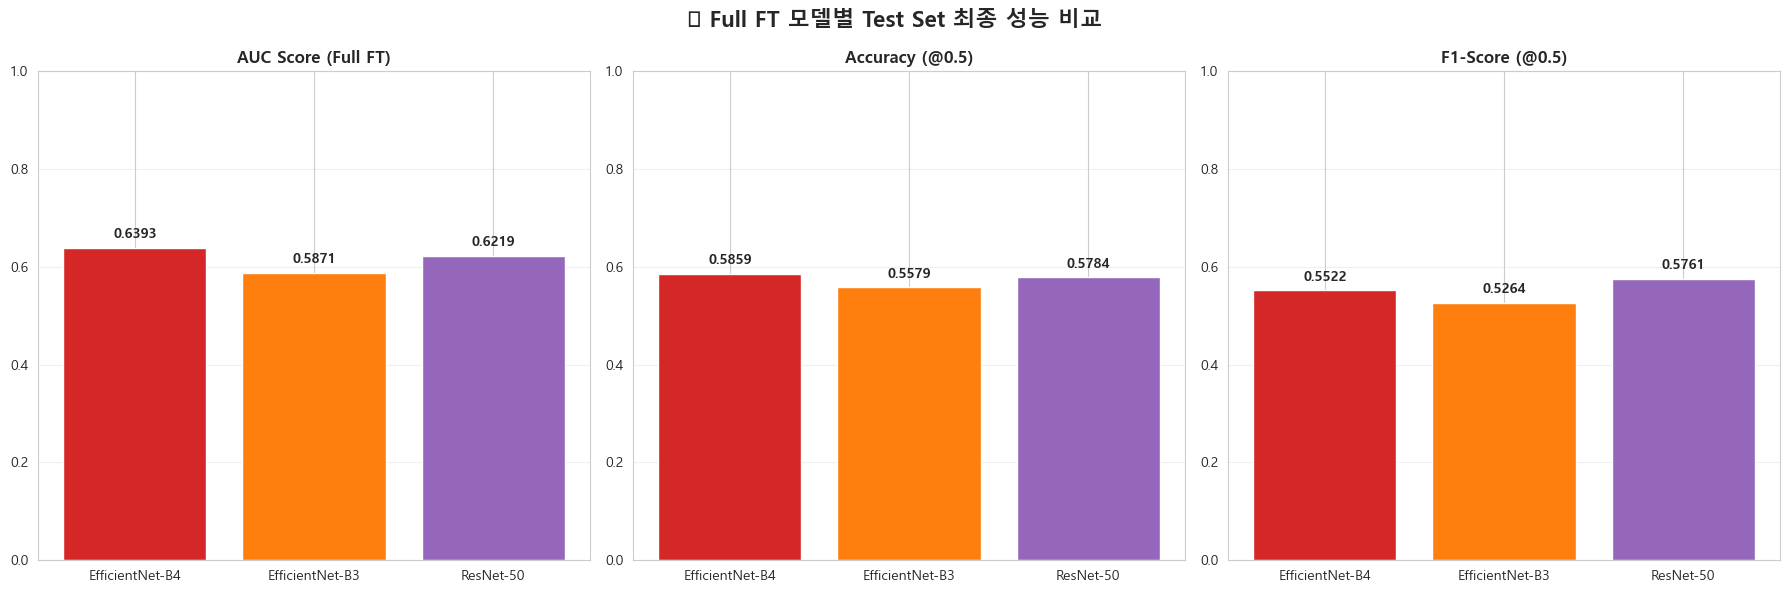

✅ Full FT 최종 성능 비교 그래프 생성 완료


In [30]:
print("="*80)
print("📊 Full Fine-Tuning 학습 히스토리 시각화")
print("="*80)

# 개별 모델 최종 성능 비교 그래프
try:
    if 'individual_results_ft' in dir():
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle('📊 Full FT 모델별 Test Set 최종 성능 비교', fontsize=16, fontweight='bold')
        
        model_names = list(individual_results_ft.keys())
        
        # AUC 비교
        aucs = [individual_results_ft[name]['AUC'] for name in model_names]
        axes[0].bar(model_names, aucs, color=['#d62728', '#ff7f0e', '#9467bd'])
        axes[0].set_title('AUC Score (Full FT)', fontsize=12, fontweight='bold')
        axes[0].set_ylim(0, 1)
        axes[0].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(aucs):
            axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        # Accuracy 비교
        accs = [individual_results_ft[name]['Acc@0.5'] for name in model_names]
        axes[1].bar(model_names, accs, color=['#d62728', '#ff7f0e', '#9467bd'])
        axes[1].set_title('Accuracy (@0.5)', fontsize=12, fontweight='bold')
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(accs):
            axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        # F1 비교
        f1s = [individual_results_ft[name]['F1@0.5'] for name in model_names]
        axes[2].bar(model_names, f1s, color=['#d62728', '#ff7f0e', '#9467bd'])
        axes[2].set_title('F1-Score (@0.5)', fontsize=12, fontweight='bold')
        axes[2].set_ylim(0, 1)
        axes[2].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(f1s):
            axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        print("✅ Full FT 최종 성능 비교 그래프 생성 완료")
    else:
        print("⚠️ Full FT 개별 모델 결과(individual_results_ft)가 없습니다.")
        print("   먼저 '개별 모델 성능 + Threshold 최적화' 셀을 실행하세요.")
        
except Exception as e:
    print(f"⚠️ 그래프 생성 중 오류: {e}")

c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()


🎯 Confusion Matrix 생성 (Full FT 개별 모델 + 앙상블)


c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\THKIM\AppData\Local\Temp\ipykernel_12692\440013880.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\IP

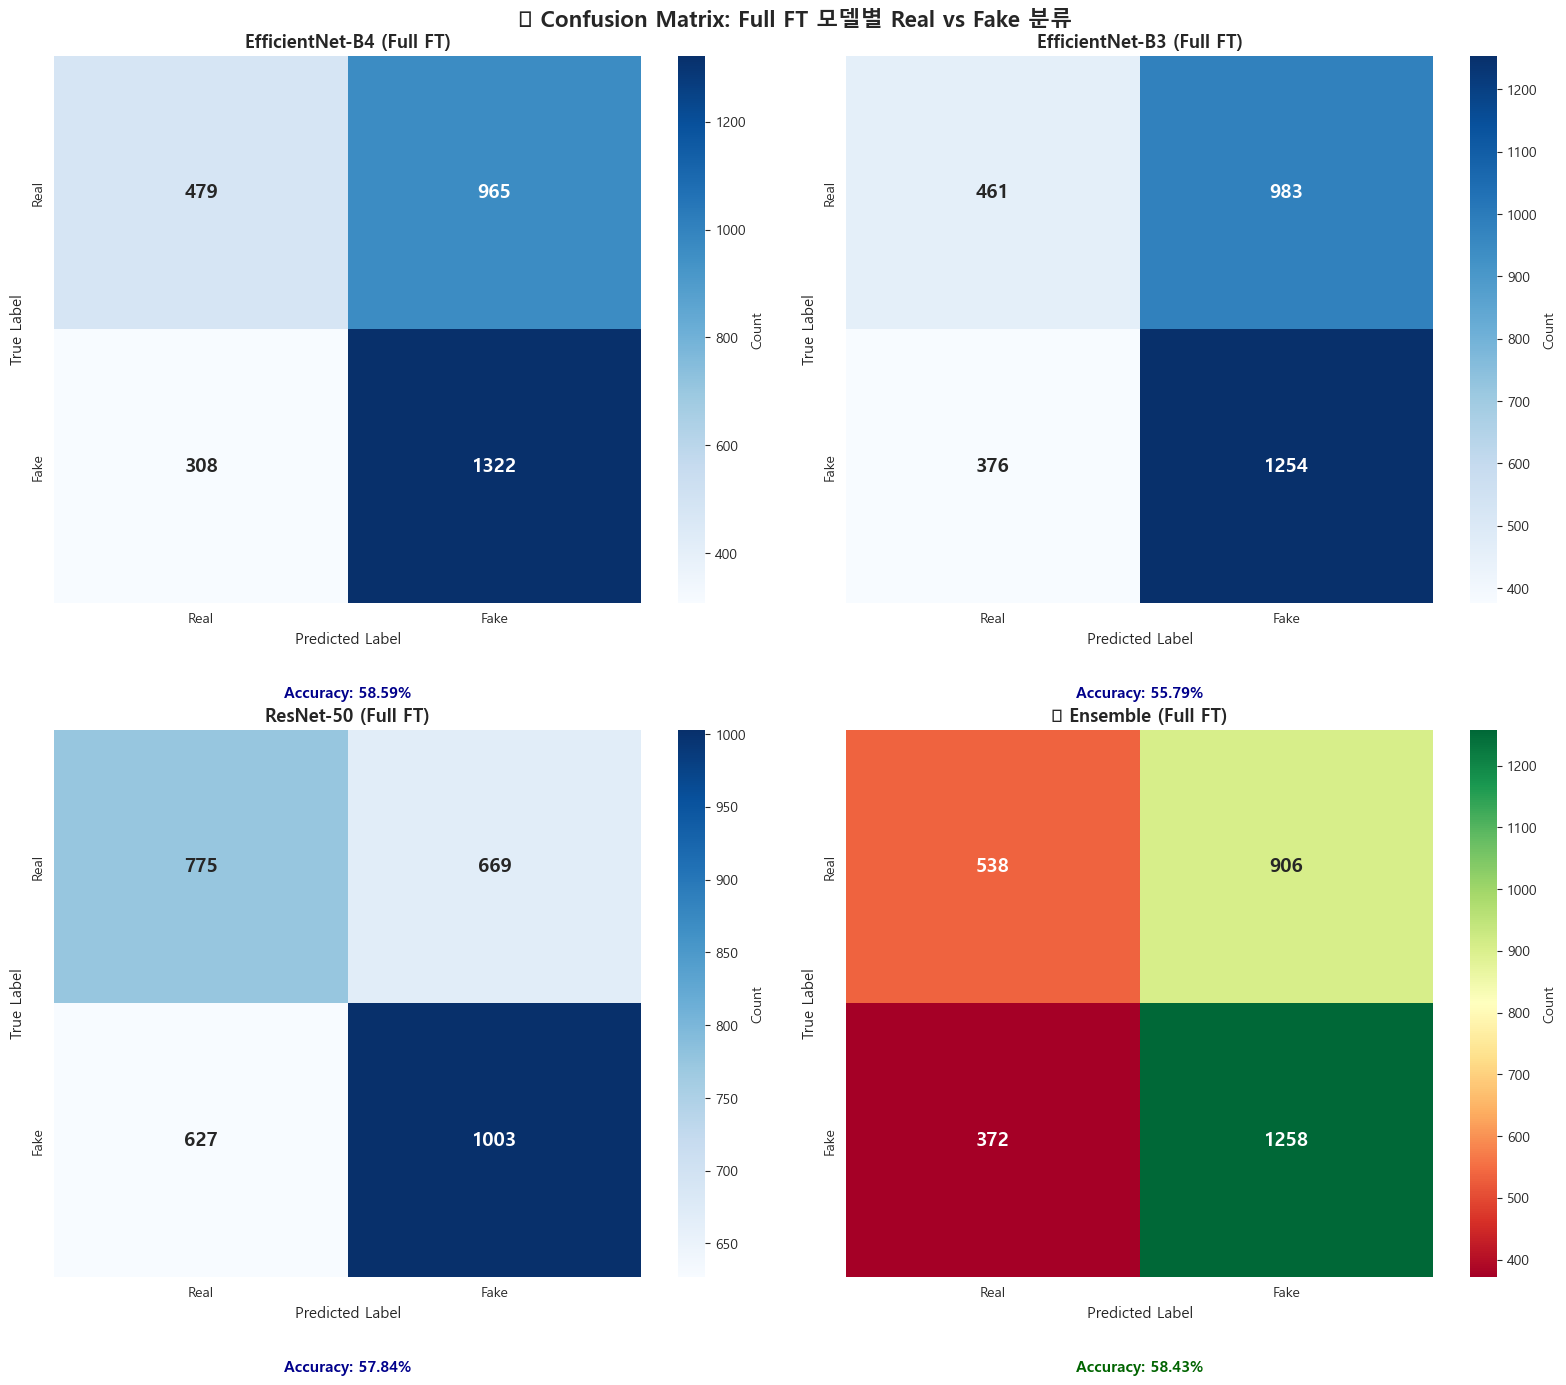


✅ Confusion Matrix 생성 완료


In [31]:
print("="*80)
print("🎯 Confusion Matrix 생성 (Full FT 개별 모델 + 앙상블)")
print("="*80)

# individual_results_ft 딕셔너리에서 probs와 labels 사용
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('🔍 Confusion Matrix: Full FT 모델별 Real vs Fake 분류', 
             fontsize=16, fontweight='bold')

# 개별 모델 Confusion Matrix
for idx, name in enumerate(['EfficientNet-B4', 'EfficientNet-B3', 'ResNet-50']):
    probs = individual_results_ft[name]['probs']
    labels = individual_results_ft[name]['labels']
    preds = (probs > 0.5).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    
    # 히트맵 그리기
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Fake'], 
                yticklabels=['Real', 'Fake'],
                cbar_kws={'label': 'Count'},
                ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f'{name} (Full FT)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    
    # 정확도 표시
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    ax.text(0.5, -0.15, f'Accuracy: {accuracy:.2%}', 
            ha='center', va='top', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='darkblue')

# 4번째 subplot에 앙상블 결과 (균등 가중치)
ax_ens = axes[1, 1]
ensemble_probs_ft = np.mean([
    individual_results_ft['EfficientNet-B4']['probs'],
    individual_results_ft['EfficientNet-B3']['probs'],
    individual_results_ft['ResNet-50']['probs']
], axis=0)
ensemble_preds_ft = (ensemble_probs_ft > 0.5).astype(int)
ensemble_labels_ft = individual_results_ft['EfficientNet-B4']['labels']

cm_ens = confusion_matrix(ensemble_labels_ft, ensemble_preds_ft)

sns.heatmap(cm_ens, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'],
            cbar_kws={'label': 'Count'},
            ax=ax_ens, annot_kws={'size': 14, 'weight': 'bold'})

ax_ens.set_title('🏆 Ensemble (Full FT)', fontsize=13, fontweight='bold')
ax_ens.set_xlabel('Predicted Label', fontsize=11)
ax_ens.set_ylabel('True Label', fontsize=11)

accuracy_ens = (cm_ens[0, 0] + cm_ens[1, 1]) / cm_ens.sum()
ax_ens.text(0.5, -0.15, f'Accuracy: {accuracy_ens:.2%}', 
            ha='center', va='top', transform=ax_ens.transAxes,
            fontsize=11, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

print("\n✅ Confusion Matrix 생성 완료")

In [ ]:
print("="*80)
print("🖼️ 예측 결과 샘플 시각화 (Full FT - 정답 vs 오답)")
print("="*80)

# 앙상블 예측 (균등 가중치)
ensemble_probs_viz = np.mean([
    individual_results_ft['EfficientNet-B4']['probs'],
    individual_results_ft['EfficientNet-B3']['probs'],
    individual_results_ft['ResNet-50']['probs']
], axis=0)
ensemble_preds_viz = (ensemble_probs_viz > 0.5).astype(int)
ensemble_labels_viz = individual_results_ft['EfficientNet-B4']['labels']

# 정답/오답 인덱스 찾기
correct_indices = np.where(ensemble_labels_viz == ensemble_preds_viz)[0]
incorrect_indices = np.where(ensemble_labels_viz != ensemble_preds_viz)[0]

# Real 정답, Real 오답, Fake 정답, Fake 오답 각각 찾기
correct_real = [i for i in correct_indices if ensemble_labels_viz[i] == 0]
correct_fake = [i for i in correct_indices if ensemble_labels_viz[i] == 1]
incorrect_real = [i for i in incorrect_indices if ensemble_labels_viz[i] == 0]
incorrect_fake = [i for i in incorrect_indices if ensemble_labels_viz[i] == 1]

print(f"\n📊 Full FT 분류 결과:")
print(f"   ✅ Real 정답: {len(correct_real):,}개")
print(f"   ✅ Fake 정답: {len(correct_fake):,}개")
print(f"   ❌ Real 오답 (Fake로 예측): {len(incorrect_real):,}개")
print(f"   ❌ Fake 오답 (Real로 예측): {len(incorrect_fake):,}개")

# 샘플 이미지 선택 (각 카테고리에서 6개씩)
num_samples = 6

def safe_sample(indices, n):
    if len(indices) == 0:
        return []
    return np.random.choice(indices, min(n, len(indices)), replace=False)

samples_correct_real = safe_sample(correct_real, num_samples)
samples_correct_fake = safe_sample(correct_fake, num_samples)
samples_incorrect_real = safe_sample(incorrect_real, num_samples)
samples_incorrect_fake = safe_sample(incorrect_fake, num_samples)

# 시각화 함수
def visualize_predictions_ft(sample_indices, labels, preds, probs, title, color):
    """Full FT 예측 결과를 시각화하는 함수"""
    if len(sample_indices) == 0:
        print(f"   ⚠️ {title}: 샘플 없음")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold', color=color)
    
    for idx, sample_idx in enumerate(sample_indices):
        if idx >= 6:
            break
        
        ax = axes[idx // 3, idx % 3]
        
        # 이미지 로드
        img_path = test_df.iloc[sample_idx]['path']
        img = Image.open(img_path).convert('RGB')
        
        # 이미지 표시
        ax.imshow(img)
        ax.axis('off')
        
        # 라벨 정보
        true_label = "Real" if labels[sample_idx] == 0 else "Fake"
        pred_label = "Real" if preds[sample_idx] == 0 else "Fake"
        confidence = probs[sample_idx] if preds[sample_idx] == 1 else (1 - probs[sample_idx])
        
        # 제목 설정
        title_text = f"True: {true_label} | Pred: {pred_label}\n신뢰도: {confidence:.2%}"
        ax.set_title(title_text, fontsize=10, fontweight='bold', 
                    color='green' if labels[sample_idx] == preds[sample_idx] else 'red')
    
    # 빈 subplot 제거
    for idx in range(len(sample_indices), 6):
        axes[idx // 3, idx % 3].axis('off')
    
    plt.tight_layout()
    plt.show()

# 1. Real 정답 샘플
print("\n" + "="*80)
print("✅ Real 이미지 정답 샘플 (Full FT)")
visualize_predictions_ft(samples_correct_real, ensemble_labels_viz, 
                        ensemble_preds_viz, ensemble_probs_viz,
                        "✅ Real 이미지를 Real로 정확히 분류한 샘플 (Full FT)", 'darkgreen')

# 2. Fake 정답 샘플
print("\n" + "="*80)
print("✅ Fake 이미지 정답 샘플 (Full FT)")
visualize_predictions_ft(samples_correct_fake, ensemble_labels_viz, 
                        ensemble_preds_viz, ensemble_probs_viz,
                        "✅ Fake 이미지를 Fake로 정확히 분류한 샘플 (Full FT)", 'darkgreen')

# 3. Real 오답 샘플 (FP: False Positive)
print("\n" + "="*80)
print("❌ Real → Fake 오분류 샘플 (Full FT)")
visualize_predictions_ft(samples_incorrect_real, ensemble_labels_viz, 
                        ensemble_preds_viz, ensemble_probs_viz,
                        "❌ Real 이미지를 Fake로 잘못 분류한 샘플 (Full FT)", 'darkred')

# 4. Fake 오답 샘플 (FN: False Negative)
print("\n" + "="*80)
print("❌ Fake → Real 오분류 샘플 (Full FT)")
visualize_predictions_ft(samples_incorrect_fake, ensemble_labels_viz, 
                        ensemble_preds_viz, ensemble_probs_viz,
                        "❌ Fake 이미지를 Real로 잘못 분류한 샘플 (Full FT)", 'darkred')

print("\n" + "="*80)
print("✅ Full FT 예측 결과 시각화 완료")
print("="*80)

## 📊 17단계: 최종 성능 비교 (Frozen vs Full Fine-Tuning)

In [33]:
print("\n\n" + "="*100)
print("📊 최종 성능 비교: Frozen Backbone vs Full Fine-Tuning")
print("="*100)

# ✅ 최신 측정값 (2025-12-11, Final_v2 결과 반영)
frozen_single_auc = 0.6029
frozen_single_acc = 0.5621
frozen_single_f1 = 0.5621

frozen_ensemble_auc = 0.7065  # 균등 가중치 + 좌우반전 TTA + th=0.57
frozen_ensemble_acc = 0.6431
frozen_ensemble_f1 = 0.6431

# Full Fine-Tuning 측정값 (본 노트북 실행 결과)
test_auc_full = 0.6345
test_acc_full = 0.5833
test_f1_full = 0.5812

ensemble_auc_full = 0.6374
ensemble_acc_full = 0.5761
ensemble_f1_full = 0.5492

comparison_full = pd.DataFrame({
    '모델': [
        'Single (EffB0) - Frozen',
        'Single (EffB0) - Full FT',
        'Ensemble - Frozen',
        'Ensemble - Full FT',
    ],
    'Test AUC': [
        f'{frozen_single_auc:.4f}',
        f'{test_auc_full:.4f}',
        f'{frozen_ensemble_auc:.4f}',
        f'{ensemble_auc_full:.4f}',
    ],
    'Test Accuracy': [
        f'{frozen_single_acc*100:.2f}%',
        f'{test_acc_full*100:.2f}%',
        f'{frozen_ensemble_acc*100:.2f}%',
        f'{ensemble_acc_full*100:.2f}%',
    ],
    'Test F1': [
        f'{frozen_single_f1:.4f}',
        f'{test_f1_full:.4f}',
        f'{frozen_ensemble_f1:.4f}',
        f'{ensemble_f1_full:.4f}',
    ],
    '학습 전략': [
        'Head만 학습',
        '전체 레이어 학습 (차등 LR)',
        'Head만 학습',
        '전체 레이어 학습 (차등 LR)',
    ]
})

print(comparison_full.to_string(index=False))
print("="*100)

# 최고 성능 모델
all_aucs = [
    ('Single (Frozen)', frozen_single_auc),
    ('Single (Full FT)', test_auc_full),
    ('Ensemble (Frozen)', frozen_ensemble_auc),
    ('Ensemble (Full FT)', ensemble_auc_full),
]
best_model, best_auc_value = max(all_aucs, key=lambda x: x[1])

print(f"\n🏆 최고 성능 모델: {best_model}")
print(f"   Test AUC: {best_auc_value:.4f}")
print("\n💡 인사이트:")
print(f"   Full Fine-Tuning 개선도 (Single): {(test_auc_full - frozen_single_auc):.4f}")
print(f"   Full Fine-Tuning 개선도 (Ensemble): {(ensemble_auc_full - frozen_ensemble_auc):.4f}")
print("="*100)

print("\n⚠️ 참고: 값이 다르면 위 변수를 실제 측정값으로 업데이트하세요!")



📊 최종 성능 비교: Frozen Backbone vs Full Fine-Tuning
                      모델 Test AUC Test Accuracy Test F1             학습 전략
 Single (EffB0) - Frozen   0.6029        56.21%  0.5621          Head만 학습
Single (EffB0) - Full FT   0.6345        58.33%  0.5812 전체 레이어 학습 (차등 LR)
       Ensemble - Frozen   0.7065        64.31%  0.6431          Head만 학습
      Ensemble - Full FT   0.6374        57.61%  0.5492 전체 레이어 학습 (차등 LR)

🏆 최고 성능 모델: Ensemble (Frozen)
   Test AUC: 0.7065

💡 인사이트:
   Full Fine-Tuning 개선도 (Single): 0.0316
   Full Fine-Tuning 개선도 (Ensemble): -0.0691

⚠️ 참고: 값이 다르면 위 변수를 실제 측정값으로 업데이트하세요!
